In [5]:
#General imports
resol = 300
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
from pathlib import Path
pi = np.pi

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

#Local imports
from src.bare_param import get_bare_param_n1, get_bare_param_n2, get_bare_param_n, get_bare_param_n_test

<h1> Fix problem parameters </h1>

In [12]:
#atom and waveguide
omega_A = 10*pi
Gamma = 5*pi

ir = 3*pi
uv = 13*pi

In [13]:
omega_0_n1, gamma_n1 = get_bare_param_n1(omega_A, Gamma, ir, uv)

omega_0_n2, gamma_n2 = get_bare_param_n2(omega_A, Gamma, ir, uv)

omega_0_n, gamma_n = get_bare_param_n(omega_A, Gamma, ir, uv, n=3)

omega_0_n_test, gamma_n_test = get_bare_param_n_test(omega_A, Gamma, ir, uv, n=3)


print(f"omega_A = {omega_A:.5f}, Gamma = {Gamma:.5f} \n --------------")
print(f"omega_0_n1 = {omega_0_n1:.5f}, gamma_n1 = {gamma_n1:.5f} \n --------------")
print(f"omega_0_n2 = {omega_0_n2:.5f}, gamma_n2 = {gamma_n2:.5f} \n --------------")
print(f"omega_0_n = {omega_0_n:.5f}, gamma_n = {gamma_n:.5f} \n --------------")
print(f"omega_0_n_test = {omega_0_n_test:.5f}, gamma_n_test = {gamma_n_test:.5f} \n --------------")

omega_A = 31.41593, Gamma = 15.70796 
 --------------
omega_0_n1 = 29.86235, gamma_n1 = 11.63514 
 --------------
omega_0_n2 = 30.24702, gamma_n2 = 11.42104 
 --------------
omega_0_n = 30.33679, gamma_n = 11.82212 
 --------------
omega_0_n_test = 30.33679, gamma_n_test = 11.82212 
 --------------


<h1> Convergence ? </h1>

In [4]:
n_tab = np.arange(1,100)
omega_0_n_tab = []
gamma_n_tab = []

for n in n_tab:
    omega_0_n, gamma_n = get_bare_param_n(omega_A, Gamma, ir, uv, n=n)
    omega_0_n_tab.append(omega_0_n)
    gamma_n_tab.append(gamma_n)

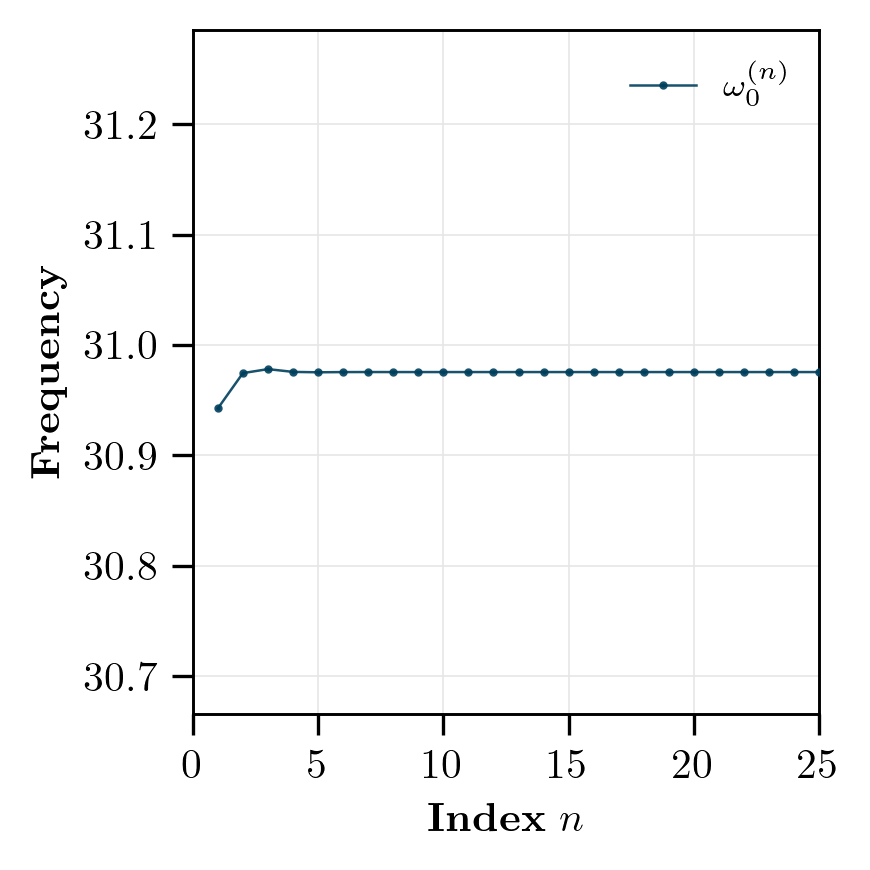

In [5]:
# Figure setup (même ADN que ta figure de référence)
fig, ax = plt.subplots(figsize=(3, 3), dpi=300)

# Palette sobre + markers distincts
color_bare_freq = "#003f5c"
color_physical_freq = "#d86a4e"


ax.plot(n_tab, omega_0_n_tab, marker="o", color=color_bare_freq, label = r'$\omega_0^{(n)}$', markersize=1, linewidth=0.6, alpha=0.9, zorder=3)


#Physical parameter
#ax.hlines(omega_A, 0, 100*pi,color=color_physical_freq, alpha=0.5, linewidth=0.8, linestyle='--', label = r'$\omega_A$')

#legend outside the plot
ax.legend(
    prop={'size': 8},
    frameon=False,
    loc='best',
    ncols=2
)

ax.set_xlim([0, 25])
ax.set_ylim([0.99*omega_0_n_tab[-1], 1.01*omega_0_n_tab[-1]])

#Switch the y-axis in pi units
#ax.yaxis.set_major_locator(ticker.MultipleLocator(base=2*pi)) 
#ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/pi:.0f}$\\pi$'))

# Labels
ax.set_xlabel(r'\textbf{Index} $n$', fontsize=13)
ax.set_ylabel(r'\textbf{Frequency}', fontsize=13)

#grid
ax.grid(color='0.9', linestyle='-', linewidth=0.4)


# Tick appearance
ax.tick_params(axis='both', which='major', length=5, width=0.8)
ax.tick_params(axis='both', which='minor', length=3, width=0.6)

#font size
for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(10)

for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(10)

plt.tight_layout()
#plt.savefig(f'../results/fig/bare_vs_physical_ir{int(ir/pi)}_uv{int(uv/pi)}.pdf')
plt.show()

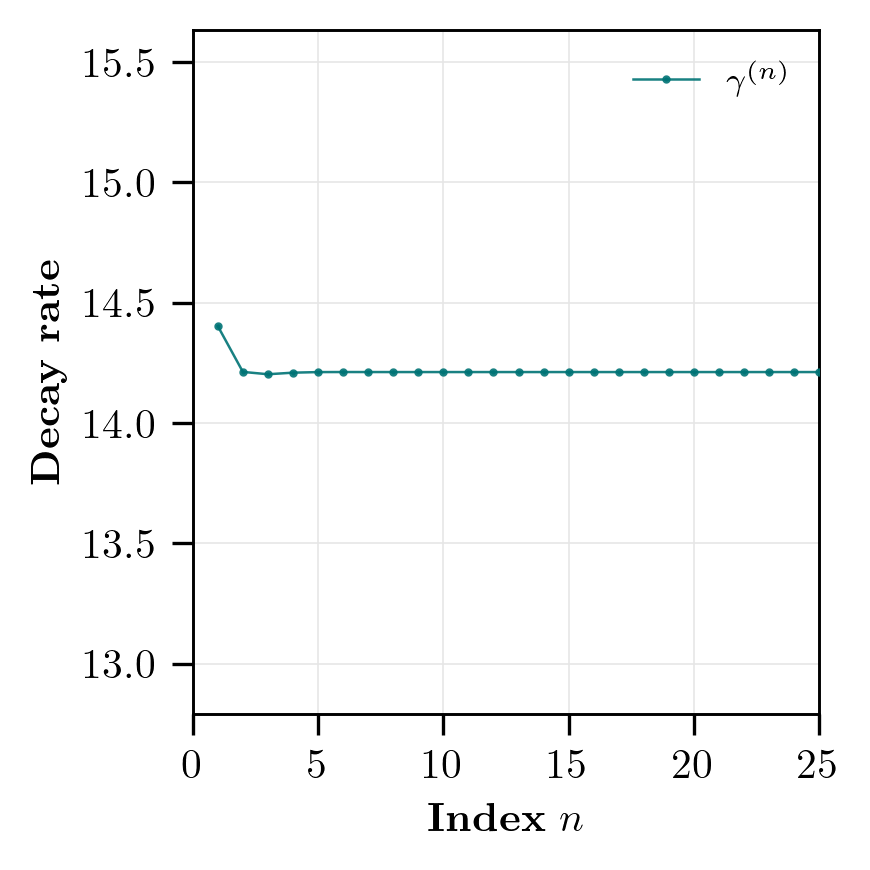

In [103]:
# Figure setup (même ADN que ta figure de référence)
fig, ax = plt.subplots(figsize=(3, 3), dpi=300)

# Palette sobre + markers distincts
color_bare_decay = "#007375"
color_physical_decay = "#b00000"

ax.plot(n_tab, gamma_n_tab, marker="o", color=color_bare_decay, label = r'$\gamma^{(n)}$', markersize=1, linewidth=0.6, alpha=0.9, zorder=3)

#legend outside the plot
ax.legend(
    prop={'size': 8},
    frameon=False,
    loc='best',
    ncols=2
)

ax.set_xlim([0, 25])
ax.set_ylim([0.9*gamma_n_tab[-1], 1.1*gamma_n_tab[-1]])

# Labels
ax.set_xlabel(r'\textbf{Index} $n$', fontsize=13)
ax.set_ylabel(r'\textbf{Decay rate}', fontsize=13)

#grid
ax.grid(color='0.9', linestyle='-', linewidth=0.4)


# Tick appearance
ax.tick_params(axis='both', which='major', length=5, width=0.8)
ax.tick_params(axis='both', which='minor', length=3, width=0.6)

#font size
for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(10)

for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(10)

plt.tight_layout()
#plt.savefig(f'../results/fig/bare_vs_physical_ir{int(ir/pi)}_uv{int(uv/pi)}.pdf')
plt.show()